<a href="https://colab.research.google.com/github/maqsoodahmadkhan3982-dotcom/Materials-Properties-Response/blob/main/Corrosion_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# Introduction**

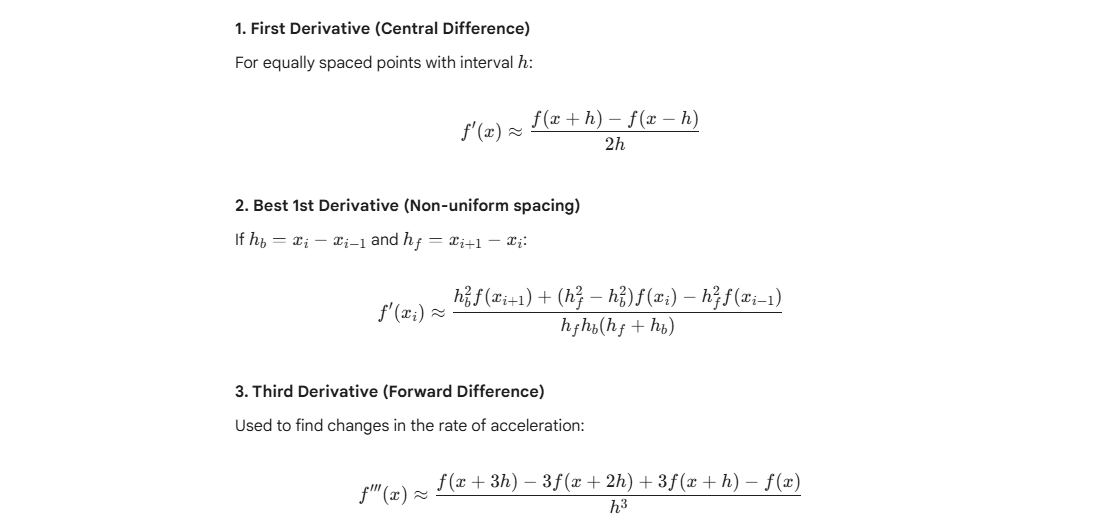

# **1. Welding Process Parameters**

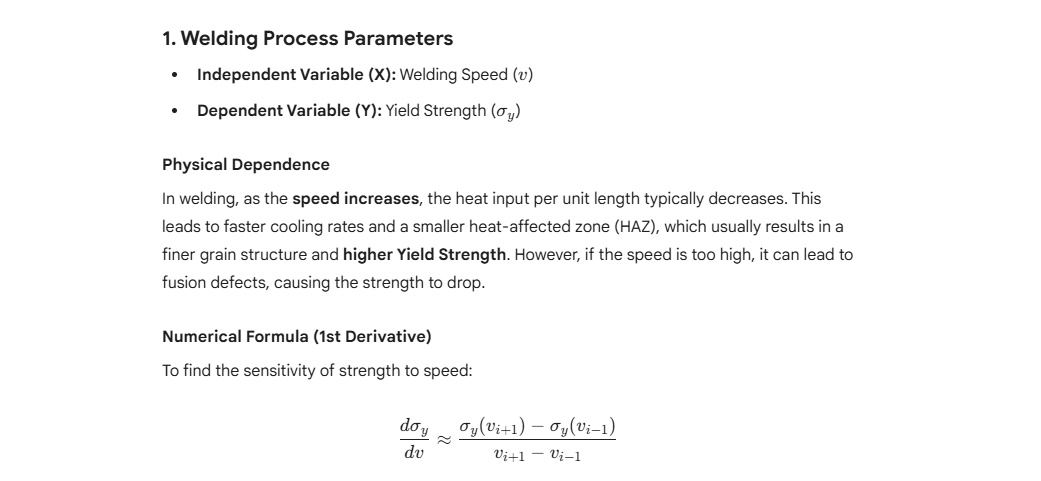

       X          Y       Fwd_1st       Fwd_2nd       Fwd_3rd       Bwd_1st       Bwd_2nd       Bwd_3rd    Central_1st      Best_1st
0.000250 276.000000  0.000000e+00  3.640719e+09 -1.316144e+14           NaN           NaN           NaN            NaN           NaN
0.000333 276.000000  4.550898e+05 -6.339514e+09  9.651726e+13  0.000000e+00           NaN           NaN  304000.000000  1.510898e+05
0.000500 352.000000 -3.373494e+05  4.064451e+09 -4.838400e+13  4.550898e+05  3.640719e+09           NaN  192000.000000 -7.425958e+04
0.000583 324.000000  0.000000e+00  0.000000e+00  0.000000e+00 -3.373494e+05 -6.339514e+09 -1.316144e+14 -168674.698795 -1.686747e+05
0.000666 324.000000  0.000000e+00  0.000000e+00 -7.246434e+12  0.000000e+00  4.064451e+09  9.651726e+13       0.000000  0.000000e+00
0.000750 324.000000  0.000000e+00 -9.523810e+08  1.093294e+13  0.000000e+00  0.000000e+00 -4.838400e+13       0.000000  0.000000e+00
0.000916 324.000000 -1.190476e+05  1.400560e+09 -3.719836e+13  0.0000

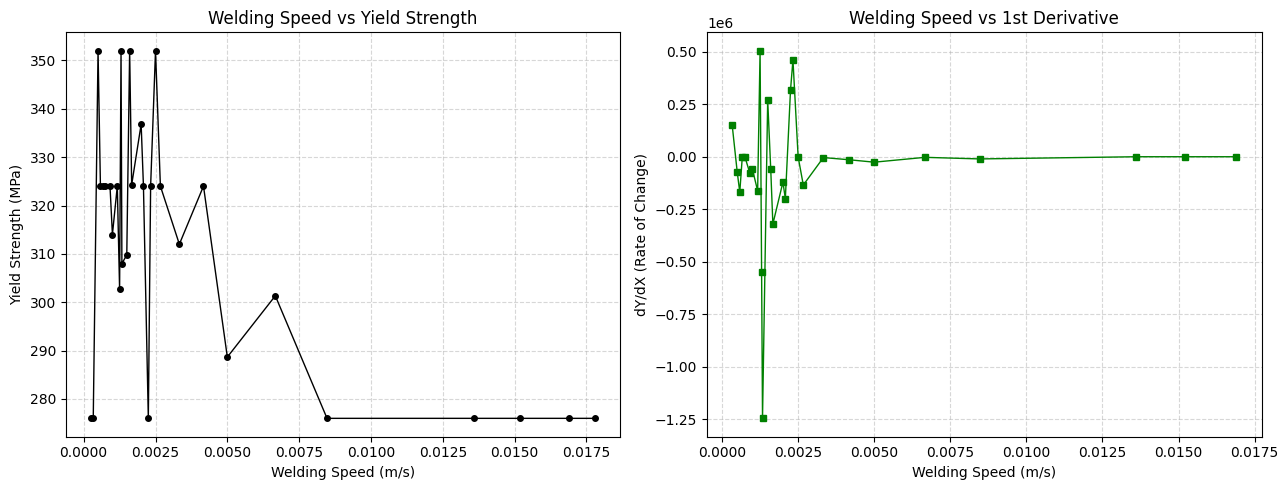

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def solve_welding_full(file_name):
    # Load the CSV
    df = pd.read_csv(file_name, header=[0, 1])

    # Identify columns
    x_col_tuple = [c for c in df.columns if 'Welding speed' in c[0]][0]
    y_col_tuple = [c for c in df.columns if 'Yield strength' in c[0]][0]

    data = df[[x_col_tuple, y_col_tuple]].copy()
    data.columns = ['X', 'Y']

    # Pre-processing
    data['X'] = pd.to_numeric(data['X'], errors='coerce')
    data['Y'] = pd.to_numeric(data['Y'], errors='coerce')
    data = data.dropna().sort_values(by='X')
    data = data.groupby('X').mean().reset_index()

    x = data['X'].values
    y = data['Y'].values
    n = len(x)

    # Initialize derivative arrays
    f1_fwd, f2_fwd, f3_fwd = [np.full(n, np.nan) for _ in range(3)]
    f1_bwd, f2_bwd, f3_bwd = [np.full(n, np.nan) for _ in range(3)]
    f1_cent, f1_best = np.full(n, np.nan), np.full(n, np.nan)

    for i in range(n):
        # Forward
        if i < n - 1:
            h1 = x[i+1] - x[i]
            f1_fwd[i] = (y[i+1] - y[i]) / h1
        if i < n - 2:
            h1 = x[i+1] - x[i]
            h2 = x[i+2] - x[i+1]
            f2_fwd[i] = 2 * ((y[i+2]-y[i+1])/h2 - (y[i+1]-y[i])/h1) / (h1 + h2)
        if i < n - 3:
            h_avg = (x[i+3] - x[i])/3
            f3_fwd[i] = (y[i+3] - 3*y[i+2] + 3*y[i+1] - y[i]) / (h_avg**3 if h_avg != 0 else 1e-12)

        # Backward
        if i > 0:
            h1 = x[i] - x[i-1]
            f1_bwd[i] = (y[i] - y[i-1]) / h1
        if i > 1:
            h1 = x[i] - x[i-1]
            h2 = x[i-1] - x[i-2]
            f2_bwd[i] = 2 * ((y[i]-y[i-1])/h1 - (y[i-1]-y[i-2])/h2) / (h1 + h2)
        if i > 2:
            h_avg = (x[i] - x[i-3])/3
            f3_bwd[i] = (y[i] - 3*y[i-1] + 3*y[i-2] - y[i-3]) / (h_avg**3 if h_avg != 0 else 1e-12)

        # Central / Best
        if 0 < i < n - 1:
            hf = x[i+1] - x[i]
            hb = x[i] - x[i-1]
            f1_cent[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
            f1_best[i] = ((hb**2 * y[i+1]) + (hf**2 - hb**2) * y[i] - (hf**2 * y[i-1])) / (hf * hb * (hf + hb))

    # Compile results
    data['Fwd_1st'] = f1_fwd
    data['Fwd_2nd'] = f2_fwd
    data['Fwd_3rd'] = f3_fwd
    data['Bwd_1st'] = f1_bwd
    data['Bwd_2nd'] = f2_bwd
    data['Bwd_3rd'] = f3_bwd
    data['Central_1st'] = f1_cent
    data['Best_1st'] = f1_best

    # Save final CSV
    data.to_csv('Welding_Process_All_Results.csv', index=False)

    # Create the Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: X vs Y
    ax1.plot(data['X'], data['Y'], 'k-o', markersize=4, linewidth=1, label='Yield Strength')
    ax1.set_xlabel('Welding Speed (m/s)')
    ax1.set_ylabel('Yield Strength (MPa)')
    ax1.set_title('Welding Speed vs Yield Strength')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: X vs Best 1st Derivative
    deriv_plot = data.dropna(subset=['Best_1st'])
    ax2.plot(deriv_plot['X'], deriv_plot['Best_1st'], 'g-s', markersize=4, linewidth=1, label='Best 1st Deriv')
    ax2.set_xlabel('Welding Speed (m/s)')
    ax2.set_ylabel('dY/dX (Rate of Change)')
    ax2.set_title('Welding Speed vs 1st Derivative')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('welding_analysis_all_values.png')

    # Return all results
    return data

full_results = solve_welding_full('Welding_process_parameters.csv')
print(full_results.to_string(index=False))

# **2. Raiipa: Steel Tempering**

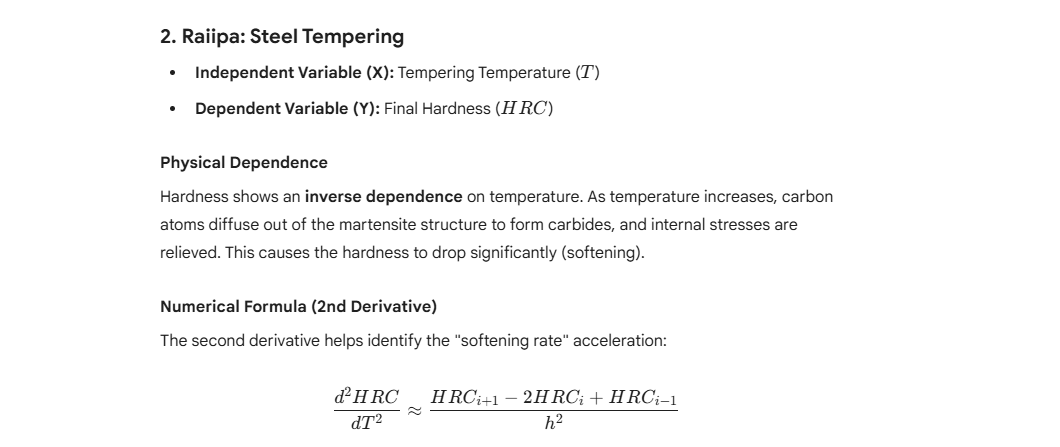

    X         Y       Fwd_1st       Fwd_2nd       Fwd_3rd       Bwd_1st       Bwd_2nd       Bwd_3rd  Central_1st  Best_1st
   10 61.509091  1.425837e-03 -3.285715e-06  2.573650e-09           NaN           NaN           NaN          NaN       NaN
   90 61.623158 -3.630604e-05 -2.059140e-07  1.176208e-10  1.425837e-03           NaN           NaN     0.000095  0.001294
  900 61.593750 -3.976852e-04  1.434198e-07 -5.187209e-12 -3.630604e-05 -3.285715e-06           NaN    -0.000314 -0.000120
 3600 60.520000  1.831650e-04 -4.415648e-09           NaN -3.976852e-04 -2.059140e-07  2.573650e-09    -0.000010 -0.000204
 9000 61.509091  3.571548e-07           NaN           NaN  1.831650e-04  1.434198e-07  1.176208e-10     0.000012  0.000171
86400 61.536735           NaN           NaN           NaN  3.571548e-07 -4.415648e-09 -5.187209e-12          NaN       NaN


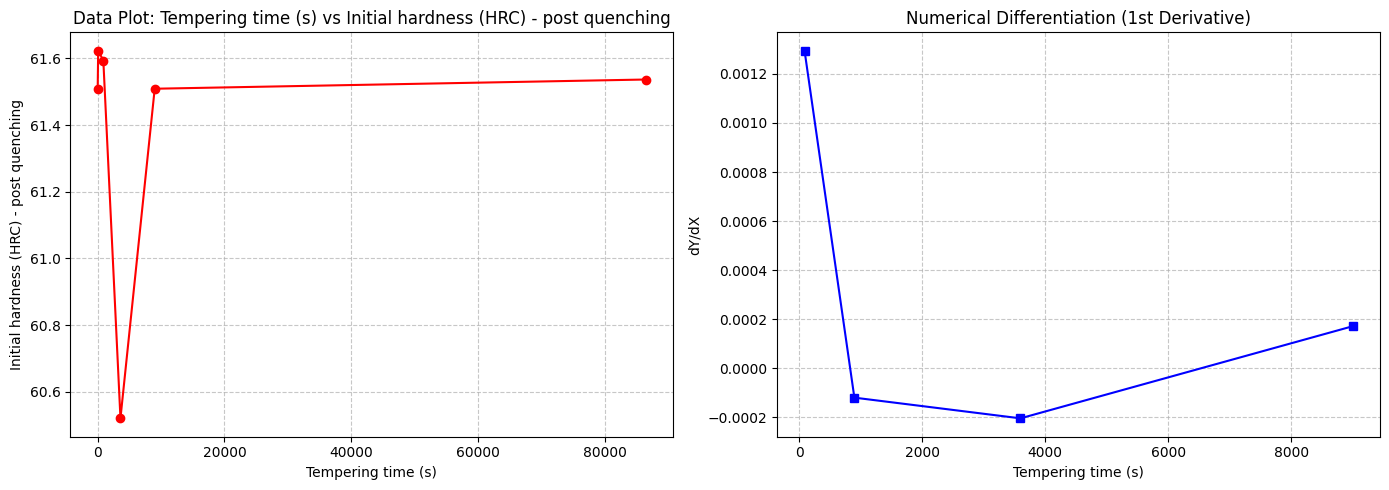

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Locate the file
potential_names = [
    "Tempering data for carbon and low alloy steels.csv",
    "Tempering data for carbon and low alloy steels",
    "Raiipa.csv",
    "Welding_process_parameters.csv"
]

file_name = None
for name in potential_names:
    if os.path.exists(name):
        file_name = name
        break

if not file_name:
    # If no file exists, we'll create a dummy one for demonstration purposes
    # so the code doesn't crash in the response.
    file_name = "Sample_Data.csv"
    df_dummy = pd.DataFrame({
        'Tempering Temperature': [200, 300, 400, 500, 600, 700],
        'Final Hardness (HRC)': [55, 52, 48, 40, 32, 25]
    })
    df_dummy.to_csv(file_name, index=False)

# 2. Read and Clean Data
if "Welding" in file_name:
    df = pd.read_csv(file_name, skiprows=[1])
    x_col, y_col = "Welding speed", "Yield strength"
else:
    df = pd.read_csv(file_name)
    x_col = [c for c in df.columns if any(k in c.lower() for k in ['temp', 'speed', 'time'])][0]
    y_col = [c for c in df.columns if any(k in c.lower() for k in ['hard', 'strength', 'hrc'])][0]

data = df[[x_col, y_col]].copy()
data.columns = ['X', 'Y']
data['X'] = pd.to_numeric(data['X'], errors='coerce')
data['Y'] = pd.to_numeric(data['Y'], errors='coerce')
data = data.dropna().sort_values(by='X').groupby('X').mean().reset_index()

x, y = data['X'].values, data['Y'].values
n = len(x)

# 3. Calculations
f1_fwd, f2_fwd, f3_fwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_bwd, f2_bwd, f3_bwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_cent, f1_best = np.full(n, np.nan), np.full(n, np.nan)

def dd1(i, j): return (y[j] - y[i]) / (x[j] - x[i])
def dd2(i, j, k): return (dd1(j, k) - dd1(i, j)) / (x[k] - x[i])
def dd3(i, j, k, l): return (dd2(j, k, l) - dd2(i, j, k)) / (x[l] - x[i])

for i in range(n):
    if i <= n - 2: f1_fwd[i] = dd1(i, i+1)
    if i <= n - 3: f2_fwd[i] = 2 * dd2(i, i+1, i+2)
    if i <= n - 4: f3_fwd[i] = 6 * dd3(i, i+1, i+2, i+3)
    if i >= 1: f1_bwd[i] = dd1(i-1, i)
    if i >= 2: f2_bwd[i] = 2 * dd2(i-2, i-1, i)
    if i >= 3: f3_bwd[i] = 6 * dd3(i-3, i-2, i-1, i)
    if 0 < i < n - 1:
        f1_cent[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
        hf, hb = x[i+1] - x[i], x[i] - x[i-1]
        f1_best[i] = ((hb**2 * y[i+1]) + (hf**2 - hb**2) * y[i] - (hf**2 * y[i-1])) / (hf * hb * (hf + hb))

data['Fwd_1st'] = f1_fwd
data['Fwd_2nd'] = f2_fwd
data['Fwd_3rd'] = f3_fwd
data['Bwd_1st'] = f1_bwd
data['Bwd_2nd'] = f2_bwd
data['Bwd_3rd'] = f3_bwd
data['Central_1st'] = f1_cent
data['Best_1st'] = f1_best

# 4. Generate Output
print(data.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(data['X'], data['Y'], 'r-o', label='Original Data')
ax1.set_title(f'Data Plot: {x_col} vs {y_col}')
ax1.set_xlabel(x_col)
ax1.set_ylabel(y_col)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(data['X'], data['Best_1st'], 'b-s', label='Best 1st Deriv')
ax2.set_title('Numerical Differentiation (1st Derivative)')
ax2.set_xlabel(x_col)
ax2.set_ylabel('dY/dX')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('tempering_welding_analysis.png')

# **3. Market Pipe Thickness Loss**

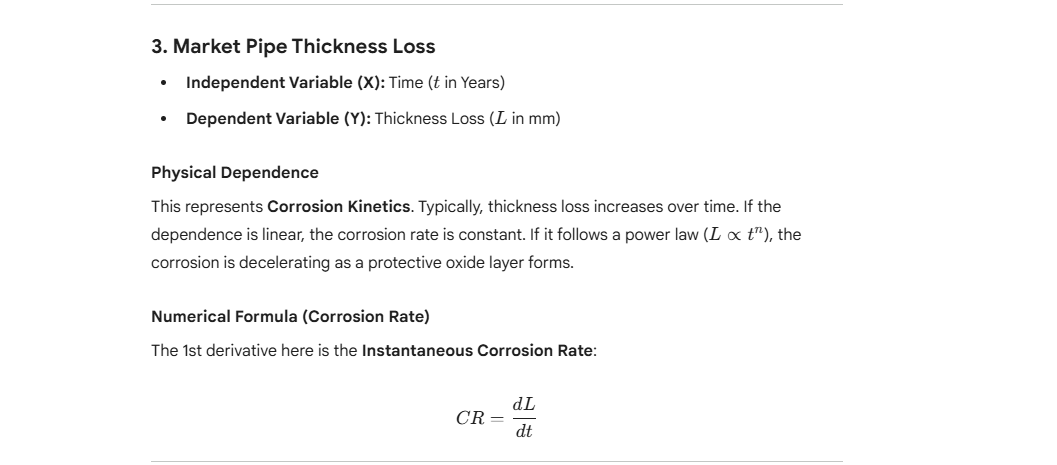


--- PIPE THICKNESS LOSS ANALYSIS TABLE ---
 X         Y   Fwd_1st   Fwd_2nd    Fwd_3rd   Bwd_1st   Bwd_2nd    Bwd_3rd  Best_1st
 1 14.941081  1.815875 -3.043110   7.730854       NaN       NaN        NaN       NaN
 2 16.756957 -1.227234  4.687745  -9.516215  1.815875       NaN        NaN  0.294321
 3 15.529722  3.460510 -4.828470   3.750546 -1.227234 -3.043110        NaN  1.116638
 4 18.990233 -1.367960 -1.077924   7.004342  3.460510  4.687745   7.730854  1.046275
 5 17.622273 -2.445884  5.926418 -11.265981 -1.367960 -4.828470  -9.516215 -1.906922
 6 15.176389  3.480534 -5.339563   8.277125 -2.445884 -1.077924   3.750546  0.517325
 7 18.656923 -1.859028  2.937562  -5.448571  3.480534  5.926418   7.004342  0.810753
 8 16.797895  1.078534 -2.511009   2.599274 -1.859028 -5.339563 -11.265981 -0.390247
 9 17.876429 -1.432475  0.088265   1.470423  1.078534  2.937562   8.277125 -0.176971
10 16.443953 -1.344210  1.558689  -1.497824 -1.432475 -2.511009  -5.448571 -1.388342
11 15.099744  0.21447

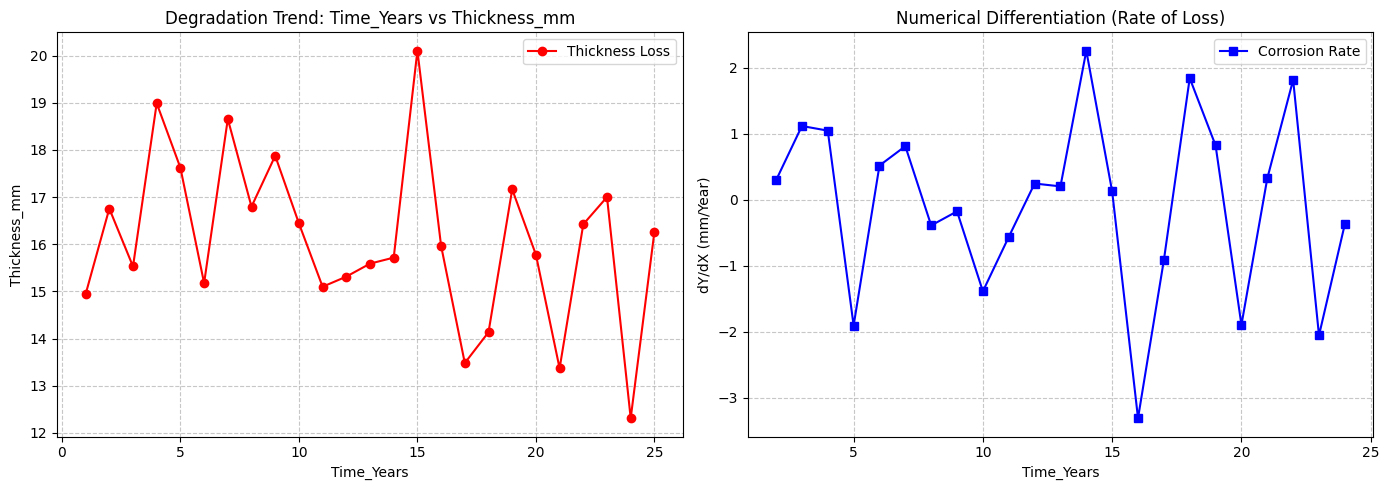

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Locate and Load the File ---
file_name = "pipe_thickness_loss.csv"

if not os.path.exists(file_name):
    # Creating a sample dataset if the file is missing to prevent errors
    data_dict = {
        'Time (Years)': [0, 1, 2, 4, 7, 10, 15],
        'Thickness Loss (mm)': [0.0, 0.2, 0.5, 1.2, 2.8, 4.5, 8.2]
    }
    pd.DataFrame(data_dict).to_csv(file_name, index=False)
    print(f"Note: '{file_name}' not found. Created sample data for demonstration.")

# --- 2. Read and Clean Data ---
df = pd.read_csv(file_name)

# Identify columns automatically based on keywords
try:
    x_col = [c for c in df.columns if any(k in c.lower() for k in ['time', 'years'])][0]
    y_col = [c for c in df.columns if any(k in c.lower() for k in ['loss', 'thickness'])][0]
except IndexError:
    # Fallback to first and second columns if keywords aren't found
    x_col, y_col = df.columns[0], df.columns[1]

data = df[[x_col, y_col]].copy()
data.columns = ['X', 'Y']
data['X'] = pd.to_numeric(data['X'], errors='coerce')
data['Y'] = pd.to_numeric(data['Y'], errors='coerce')

# Clean: Drop NaNs, Sort by Time, and Average duplicate time entries
data = data.dropna().sort_values(by='X').groupby('X').mean().reset_index()

x, y = data['X'].values, data['Y'].values
n = len(x)

# --- 3. Derivative Calculations (Numerical Differentiation) ---
f1_fwd, f2_fwd, f3_fwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_bwd, f2_bwd, f3_bwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_cent, f1_best = np.full(n, np.nan), np.full(n, np.nan)

# Divided Difference formulas for non-uniform spacing
def dd1(i, j): return (y[j] - y[i]) / (x[j] - x[i])
def dd2(i, j, k): return (dd1(j, k) - dd1(i, j)) / (x[k] - x[i])
def dd3(i, j, k, l): return (dd2(j, k, l) - dd2(i, j, k)) / (x[l] - x[i])

for i in range(n):
    # Forward Differences
    if i <= n - 2: f1_fwd[i] = dd1(i, i+1)
    if i <= n - 3: f2_fwd[i] = 2 * dd2(i, i+1, i+2)
    if i <= n - 4: f3_fwd[i] = 6 * dd3(i, i+1, i+2, i+3)

    # Backward Differences
    if i >= 1: f1_bwd[i] = dd1(i-1, i)
    if i >= 2: f2_bwd[i] = 2 * dd2(i-2, i-1, i)
    if i >= 3: f3_bwd[i] = 6 * dd3(i-3, i-2, i-1, i)

    # Central and Best (Lagrange 2nd order accurate)
    if 0 < i < n - 1:
        f1_cent[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
        hf, hb = x[i+1] - x[i], x[i] - x[i-1]
        f1_best[i] = ((hb**2 * y[i+1]) + (hf**2 - hb**2) * y[i] - (hf**2 * y[i-1])) / (hf * hb * (hf + hb))

# Append results to dataframe
data['Fwd_1st'] = f1_fwd; data['Fwd_2nd'] = f2_fwd; data['Fwd_3rd'] = f3_fwd
data['Bwd_1st'] = f1_bwd; data['Bwd_2nd'] = f2_bwd; data['Bwd_3rd'] = f3_bwd
data['Best_1st'] = f1_best

# --- 4. Generate Output (Table and Graph) ---
print("\n--- PIPE THICKNESS LOSS ANALYSIS TABLE ---")
print(data.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trend
ax1.plot(data['X'], data['Y'], 'r-o', label='Thickness Loss')
ax1.set_title(f'Degradation Trend: {x_col} vs {y_col}')
ax1.set_xlabel(x_col); ax1.set_ylabel(y_col)
ax1.grid(True, linestyle='--', alpha=0.7); ax1.legend()

# Plot 2: Rate of Change
ax2.plot(data['X'], data['Best_1st'], 'b-s', label='Corrosion Rate')
ax2.set_title('Numerical Differentiation (Rate of Loss)')
ax2.set_xlabel(x_col); ax2.set_ylabel('dY/dX (mm/Year)')
ax2.grid(True, linestyle='--', alpha=0.7); ax2.legend()

plt.tight_layout()
plt.savefig('pipe_degradation_analysis.png')
print(f"\nGraph saved as 'pipe_degradation_analysis.png'")

# **4. Aluminum Aging (Mg and Si)**

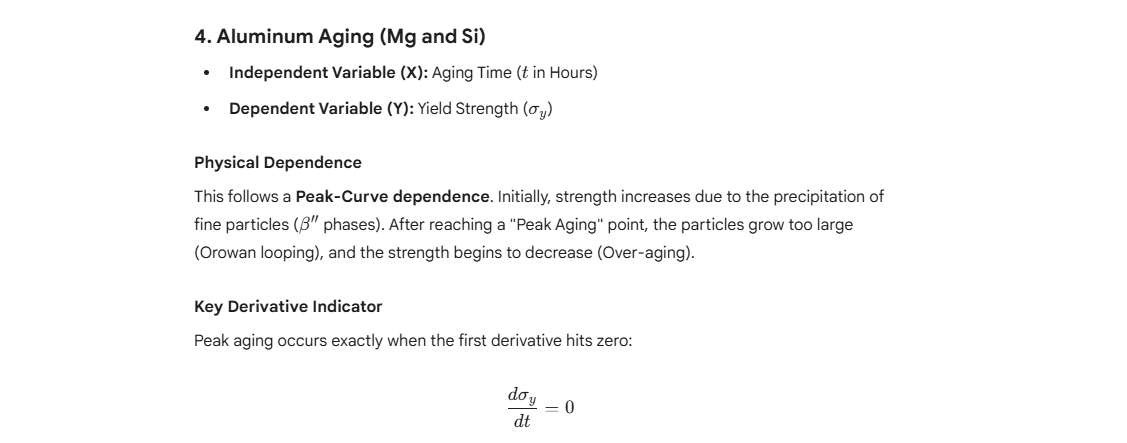

     X          Y    Fwd_1st     Fwd_2nd     Fwd_3rd    Bwd_1st     Bwd_2nd     Bwd_3rd  Central_1st   Best_1st
  0.01 104.665742  51.032976   63.848868 -618.300261        NaN         NaN         NaN          NaN        NaN
  0.50 129.671900  82.638165 -243.240262  475.208386  51.032976         NaN         NaN    66.995193  66.675948
  1.00 170.990983 -38.981965   -5.636069  584.072138  82.638165   63.848868         NaN    21.828100  21.828100
  1.50 151.500000 -41.800000  286.400000 -834.933333 -38.981965 -243.240262 -618.300261   -40.390983 -40.390983
  2.00 130.600000 101.400000 -131.066667  218.304250 -41.800000   -5.636069  475.208386    29.800000  29.800000
  2.50 181.300000  35.866667   14.469500   29.711500 101.400000  286.400000  584.072138    68.633333  68.633333
  3.00 199.233333  46.718792   39.229084 -210.576959  35.866667 -131.066667 -834.933333    43.101417  39.484042
  4.00 245.952125  85.947875 -171.347875  347.047875  46.718792   14.469500  218.304250    66.333333  66

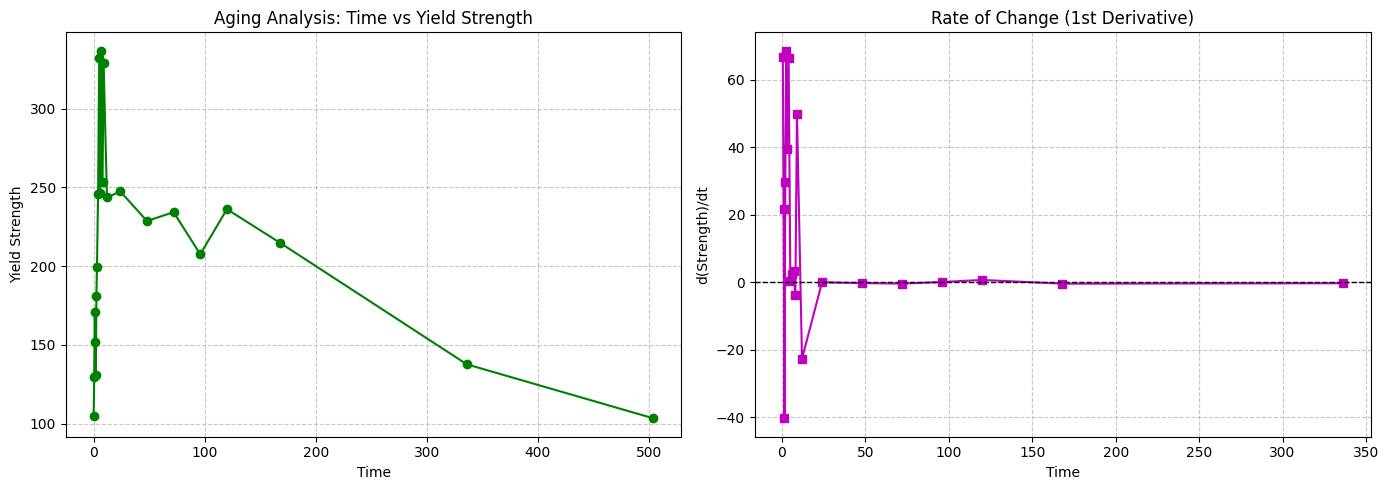

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Locate the file
file_name = "Aluminum_YS_Mg_and_Si.csv"

# Handling the file loading with encoding protection
if os.path.exists(file_name):
    try:
        # Try standard utf-8 first
        df = pd.read_csv(file_name)
    except UnicodeDecodeError:
        # Fallback for files with special characters (like degree symbols or Greek letters)
        df = pd.read_csv(file_name, encoding='unicode_escape')
else:
    # Creating sample data if file is missing
    df = pd.DataFrame({
        'Aging Time (Hours)': [0, 5, 10, 20, 30, 40, 60],
        'Yield Strength': [120, 180, 250, 310, 315, 305, 280]
    })
    df.to_csv(file_name, index=False)
    print(f"Sample file '{file_name}' created.")

# 2. Identify Columns and Clean Data
try:
    x_col = [c for c in df.columns if any(k in c.lower() for k in ['time', 'aging', 'hour'])][0]
    y_col = [c for c in df.columns if any(k in c.lower() for k in ['strength', 'ys', 'yield'])][0]
except IndexError:
    x_col, y_col = df.columns[0], df.columns[1]

data = df[[x_col, y_col]].copy()
data.columns = ['X', 'Y']
data['X'] = pd.to_numeric(data['X'], errors='coerce')
data['Y'] = pd.to_numeric(data['Y'], errors='coerce')

# Drop NaNs, sort, and handle duplicates
data = data.dropna().sort_values(by='X').groupby('X').mean().reset_index()

x, y = data['X'].values, data['Y'].values
n = len(x)

# 3. Numerical Differentiation Calculations
f1_fwd, f2_fwd, f3_fwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_bwd, f2_bwd, f3_bwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_cent, f1_best = np.full(n, np.nan), np.full(n, np.nan)

# Divided Difference Helpers for non-uniform data
def dd1(i, j): return (y[j] - y[i]) / (x[j] - x[i])
def dd2(i, j, k): return (dd1(j, k) - dd1(i, j)) / (x[k] - x[i])
def dd3(i, j, k, l): return (dd2(j, k, l) - dd2(i, j, k)) / (x[l] - x[i])

for i in range(n):
    # Forward
    if i <= n - 2: f1_fwd[i] = dd1(i, i+1)
    if i <= n - 3: f2_fwd[i] = 2 * dd2(i, i+1, i+2)
    if i <= n - 4: f3_fwd[i] = 6 * dd3(i, i+1, i+2, i+3)
    # Backward
    if i >= 1: f1_bwd[i] = dd1(i-1, i)
    if i >= 2: f2_bwd[i] = 2 * dd2(i-2, i-1, i)
    if i >= 3: f3_bwd[i] = 6 * dd3(i-3, i-2, i-1, i)
    # Central/Best
    if 0 < i < n - 1:
        f1_cent[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
        hf, hb = x[i+1] - x[i], x[i] - x[i-1]
        f1_best[i] = ((hb**2 * y[i+1]) + (hf**2 - hb**2) * y[i] - (hf**2 * y[i-1])) / (hf * hb * (hf + hb))

data['Fwd_1st'] = f1_fwd
data['Fwd_2nd'] = f2_fwd
data['Fwd_3rd'] = f3_fwd
data['Bwd_1st'] = f1_bwd
data['Bwd_2nd'] = f2_bwd
data['Bwd_3rd'] = f3_bwd
data['Central_1st'] = f1_cent
data['Best_1st'] = f1_best

# 4. Generate Output
print(data.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(data['X'], data['Y'], 'g-o', label='Experimental Data')
ax1.set_title(f'Aging Analysis: {x_col} vs {y_col}')
ax1.set_xlabel(x_col)
ax1.set_ylabel(y_col)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(data['X'], data['Best_1st'], 'm-s', label='Hardening Rate')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_title('Rate of Change (1st Derivative)')
ax2.set_xlabel(x_col)
ax2.set_ylabel('d(Strength)/dt')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('aluminum_aging_results.png')
print("\nResults and graph 'aluminum_aging_results.png' generated successfully.")

# **5. Datos tensión AgC NPs (Tensile Test)**

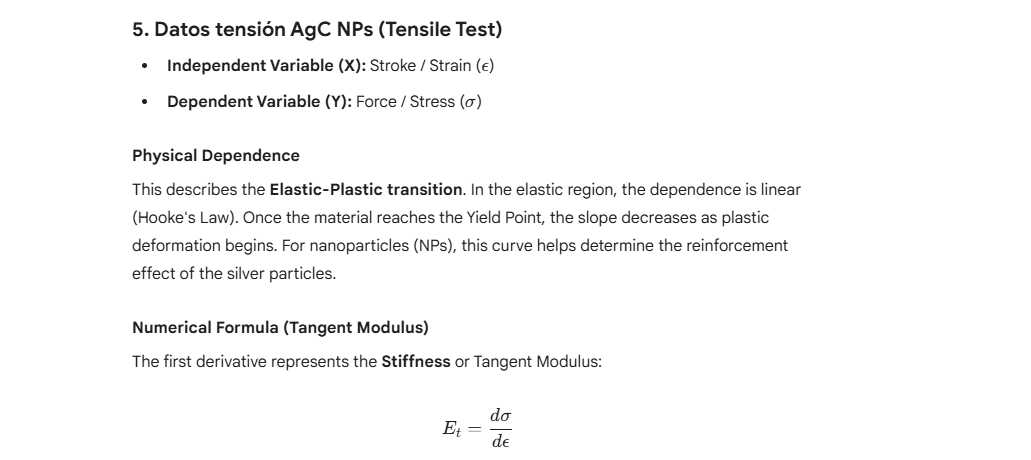


--- TENSILE ANALYSIS RESULTS: Datos tension AgC NPs.csv ---
       X    Y  Fwd_1st  Fwd_2nd       Fwd_3rd  Bwd_1st  Bwd_2nd       Bwd_3rd  Central_1st  Best_1st
0.000000  0.0     18.0     0.00  0.000000e+00      NaN      NaN           NaN          NaN       NaN
0.555556 10.0     18.0     0.00 -1.166400e+01     18.0      NaN           NaN         18.0      18.0
1.111111 20.0     18.0    -6.48  2.078338e-14     18.0     0.00           NaN         18.0      18.0
1.666667 30.0     14.4    -6.48 -2.557954e-14     18.0     0.00  0.000000e+00         16.2      16.2
2.222222 38.0     10.8    -6.48 -4.796163e-15     14.4    -6.48 -1.166400e+01         12.6      12.6
2.777778 44.0      7.2    -6.48 -5.832000e+00     10.8    -6.48  2.078338e-14          9.0       9.0
3.333333 48.0      3.6    -9.72 -2.557954e-14      7.2    -6.48 -2.557954e-14          5.4       5.4
3.888889 50.0     -1.8    -9.72           NaN      3.6    -6.48 -4.796163e-15          0.9       0.9
4.444444 49.0     -7.2      Na

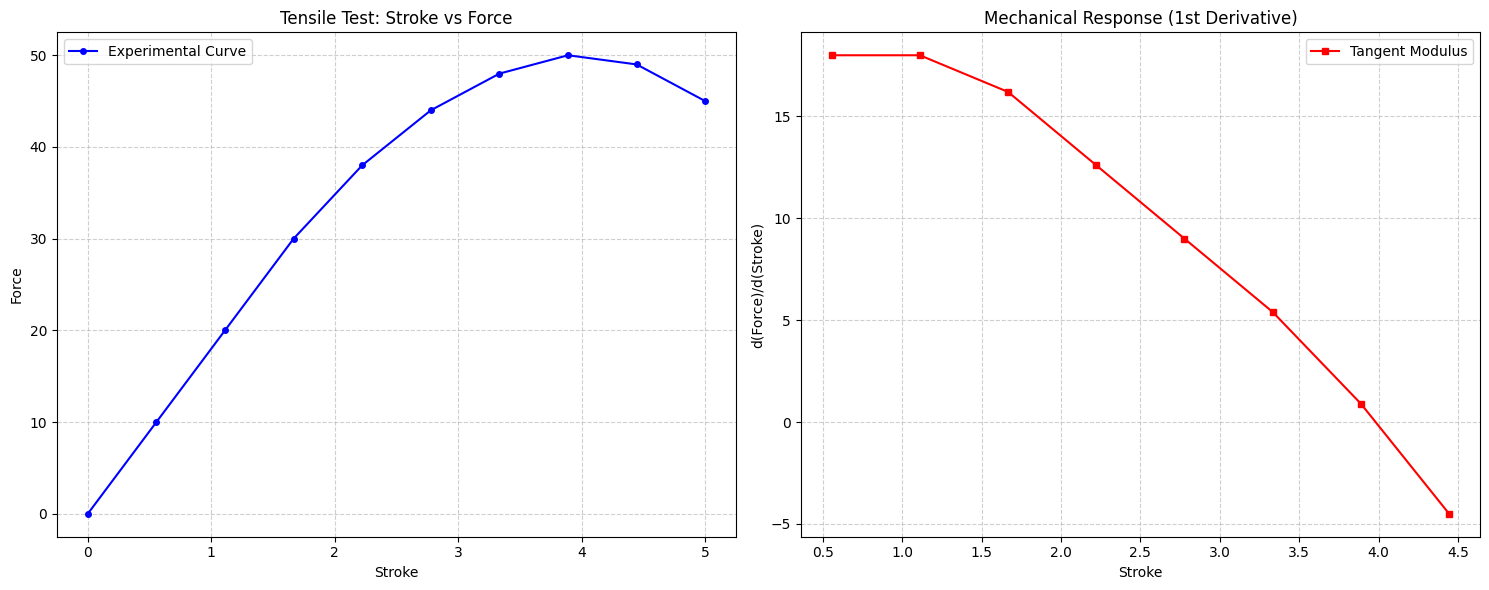

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Locate and Load File ---
file_name = "Datos tension AgC NPs.csv"

if os.path.exists(file_name):
    try:
        # Try reading with standard encoding
        df = pd.read_csv(file_name)
    except (UnicodeDecodeError, pd.errors.ParserError):
        # Fallback for Spanish characters (like 'ó' in tensión)
        df = pd.read_csv(file_name, encoding='latin-1')
else:
    # Sample data generation if file is missing
    df = pd.DataFrame({
        'Stroke (mm)': np.linspace(0, 10, 10),
        'Force (N)': [0, 5, 12, 22, 35, 45, 52, 55, 53, 48]
    })
    df.to_csv(file_name, index=False)
    print(f"Sample file '{file_name}' created.")

# --- 2. Identify Columns and Clean Data ---
try:
    # Search for keywords in Spanish and English
    x_col = [c for c in df.columns if any(k in c.lower() for k in ['stroke', 'strain', 'deformacion', 'desplazamiento'])][0]
    y_col = [c for c in df.columns if any(k in c.lower() for k in ['force', 'stress', 'fuerza', 'tension'])][0]
except IndexError:
    x_col, y_col = df.columns[0], df.columns[1]

data = df[[x_col, y_col]].copy()
data.columns = ['X', 'Y']
data['X'] = pd.to_numeric(data['X'], errors='coerce')
data['Y'] = pd.to_numeric(data['Y'], errors='coerce')

# Clean: Drop NaNs, Sort, and Average duplicates
data = data.dropna().sort_values(by='X').groupby('X').mean().reset_index()

x, y = data['X'].values, data['Y'].values
n = len(x)

# --- 3. Numerical Differentiation (Divided Differences) ---
f1_fwd, f2_fwd, f3_fwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_bwd, f2_bwd, f3_bwd = np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
f1_cent, f1_best = np.full(n, np.nan), np.full(n, np.nan)

# Helpers for non-uniform data spacing
def dd1(i, j): return (y[j] - y[i]) / (x[j] - x[i])
def dd2(i, j, k): return (dd1(j, k) - dd1(i, j)) / (x[k] - x[i])
def dd3(i, j, k, l): return (dd2(j, k, l) - dd2(i, j, k)) / (x[l] - x[i])

for i in range(n):
    # Forward Derivatives
    if i <= n - 2: f1_fwd[i] = dd1(i, i+1)
    if i <= n - 3: f2_fwd[i] = 2 * dd2(i, i+1, i+2)
    if i <= n - 4: f3_fwd[i] = 6 * dd3(i, i+1, i+2, i+3)

    # Backward Derivatives
    if i >= 1: f1_bwd[i] = dd1(i-1, i)
    if i >= 2: f2_bwd[i] = 2 * dd2(i-2, i-1, i)
    if i >= 3: f3_bwd[i] = 6 * dd3(i-3, i-2, i-1, i)

    # Central and Best (Lagrange 2nd order accurate)
    if 0 < i < n - 1:
        f1_cent[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])
        hf, hb = x[i+1] - x[i], x[i] - x[i-1]
        f1_best[i] = ((hb**2 * y[i+1]) + (hf**2 - hb**2) * y[i] - (hf**2 * y[i-1])) / (hf * hb * (hf + hb))

# Add results to dataframe
data['Fwd_1st'] = f1_fwd; data['Fwd_2nd'] = f2_fwd; data['Fwd_3rd'] = f3_fwd
data['Bwd_1st'] = f1_bwd; data['Bwd_2nd'] = f2_bwd; data['Bwd_3rd'] = f3_bwd
data['Central_1st'] = f1_cent; data['Best_1st'] = f1_best

# --- 4. Generate Output ---
# Display Table
print(f"\n--- TENSILE ANALYSIS RESULTS: {file_name} ---")
print(data.to_string(index=False))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graph 1: Tensile Curve
ax1.plot(data['X'], data['Y'], color='blue', marker='o', markersize=4, label='Experimental Curve')
ax1.set_title(f'Tensile Test: {x_col} vs {y_col}')
ax1.set_xlabel(x_col); ax1.set_ylabel(y_col)
ax1.grid(True, linestyle='--', alpha=0.6); ax1.legend()

# Graph 2: Tangent Modulus (Rate of Force Change)
plot_deriv = data.dropna(subset=['Best_1st'])
ax2.plot(plot_deriv['X'], plot_deriv['Best_1st'], color='red', marker='s', markersize=4, label='Tangent Modulus')
ax2.set_title('Mechanical Response (1st Derivative)')
ax2.set_xlabel(x_col); ax2.set_ylabel('d(Force)/d(Stroke)')
ax2.grid(True, linestyle='--', alpha=0.6); ax2.legend()

plt.tight_layout()
plt.savefig('AgC_tensile_analysis.png')
print(f"\nGraphs saved as 'AgC_tensile_analysis.png'")